In [4]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 707.3 kB/s eta 0:00:00 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 42.4 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 94.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 69.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 936.9/936.9 kB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.9/214.9 kB 15.0 MB/s eta 0:00:00


In [5]:
import mlflow

In [6]:
import json
import ast
import copy
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, precision_score, recall_score, accuracy_score, confusion_matrix, classification_report
import torch
from torch import nn
from torch.utils.data import Dataset, TensorDataset, DataLoader

import mlflow
import mlflow.pytorch
import mlflow.sklearn
use_mlflow = True

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json
import ast
from pathlib import Path

In [8]:
random_state = 67
np.random.seed(random_state)
torch.manual_seed(random_state)

In [9]:
directory_data = Path("/kaggle/input/datasets/organizations/yelp-dataset/yelp-dataset")
business_json = directory_data /"yelp_academic_dataset_business.json"
review_json = directory_data /"yelp_academic_dataset_review.json"
checkin_json = directory_data /"yelp_academic_dataset_checkin.json"

# eda

у нас очень-очень много городов да и америка у нас большая, как же нам сузить весь этот выбор? в помощь нам еда. 

посмотрим сначала просто что за данные

In [11]:
df = pd.read_json(business_json, lines=True)
df.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",None
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,1,"{'BusinessAcceptsCreditCards': 'True', 'Wheelc...","Brewpubs, Breweries, Food","{'Wednesday': '14:0-22:0', 'Thursday': '16:0-2..."


In [12]:
df.describe()

,latitude,longitude,stars,review_count,is_open
count,150346.000000,150346.000000,150346.000000,150346.000000,150346.00000
mean,36.671150,-89.357339,3.596724,44.866561,0.79615
std,5.872759,14.918502,0.974421,121.120136,0.40286
min,27.555127,-120.095137,1.000000,5.000000,0.00000
25%,32.187293,-90.357810,3.000000,8.000000,1.00000
50%,38.777413,-86.121179,3.500000,15.000000,1.00000
75%,39.954036,-75.421542,4.500000,37.000000,1.00000
max,53.679197,-73.200457,5.000000,7568.000000,1.00000


В датасете `business.json` каждая строка соответствует одному бизнесу на Yelp. Для дальнейшего анализа важны поля `business_id`, `city`, `state`, `categories`, `stars`, `review_count`, `attributes`, `hours` и координаты. Поля `stars` и `review_count` используются только для описательного анализа, но не будут включаться в модель, чтобы избежать утечки данных.

Давайте сделаем фильтр по ресторанам и посмотрим на вообще что у нас есть

In [13]:
df = df[df['categories'].notna()].copy()
rest = df[df["categories"].str.contains("Restaurants", case=False)].copy()
rest.shape

(52268, 14)

всего 52268 ресторанов - представим как там будет выглядеть датасет если мы все их будем смотреть! ужас. нужно выбрать город, походящий на москву.

In [14]:
rest.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
5,CF33F8-E6oudUQ46HnavjQ,Sonic Drive-In,615 S Main St,Ashland City,TN,37015,36.269593,-87.058943,2.0,6,1,"{'BusinessParking': 'None', 'BusinessAcceptsCr...","Burgers, Fast Food, Sandwiches, Food, Ice Crea...","{'Monday': '0:0-0:0', 'Tuesday': '6:0-22:0', '..."
8,k0hlBqXX-Bt0vf1op7Jr1w,Tsevi's Pub And Grill,8025 Mackenzie Rd,Affton,MO,63123,38.565165,-90.321087,3.0,19,0,"{'Caters': 'True', 'Alcohol': 'u'full_bar'', '...","Pubs, Restaurants, Italian, Bars, American (Tr...",None
9,bBDDEgkFA1Otx9Lfe7BZUQ,Sonic Drive-In,2312 Dickerson Pike,Nashville,TN,37207,36.208102,-86.768170,1.5,10,1,"{'RestaurantsAttire': ''casual'', 'Restaurants...","Ice Cream & Frozen Yogurt, Fast Food, Burgers,...","{'Monday': '0:0-0:0', 'Tuesday': '6:0-21:0', '..."
11,eEOYSgkmpB90uNA7lDOMRA,Vietnamese Food Truck,,Tampa Bay,FL,33602,27.955269,-82.456320,4.0,10,1,"{'Alcohol': ''none'', 'OutdoorSeating': 'None'...","Vietnamese, Food, Restaurants, Food Trucks","{'Monday': '11:0-14:0', 'Tuesday': '11:0-14:0'..."


In [15]:
rest.describe()

,latitude,longitude,stars,review_count,is_open
count,52268.000000,52268.000000,52268.000000,52268.000000,52268.000000
mean,36.997628,-87.842454,3.515172,87.267142,0.669377
std,6.011376,13.811197,0.829593,188.939711,0.470442
min,27.564457,-120.083748,1.000000,5.000000,0.000000
25%,32.217692,-90.233246,3.000000,13.000000,0.000000
50%,39.484107,-86.035524,3.500000,33.000000,1.000000
75%,39.958359,-75.337576,4.000000,89.000000,1.000000
max,53.679197,-74.664459,5.000000,7568.000000,1.000000


Давайте посчитаем по каждому городу:

1. среднее по звездам;
2. количество ресторанов;
3. количество отзывов;
4. среднюю долю открытых заведений.

И выведем топ городов по количеству ресторанов.

In [16]:
city_stats = (
    rest
    .groupby("city")
    .agg(
        n_restaurants=("business_id", "nunique"),
        avg_business_stars=("stars", "mean"),
        median_business_stars=("stars", "median"),
        total_business_review_count=("review_count", "sum"),
        avg_business_review_count=("review_count", "mean"),
        median_business_review_count=("review_count", "median"),
        open_rate=("is_open", "mean")
    )
    .reset_index()
    .sort_values("n_restaurants", ascending=False)
)

city_stats.head(20)

,city,n_restaurants,avg_business_stars,median_business_stars,total_business_review_count,avg_business_review_count,median_business_review_count,open_rate
577,Philadelphia,5852,3.555964,3.5,665732,113.761449,38.5,0.602358
761,Tampa,2960,3.603378,4.0,293122,99.027703,37.0,0.663514
344,Indianapolis,2862,3.490566,3.5,242024,84.564640,33.0,0.665269
508,Nashville,2502,3.564149,3.5,318548,127.317346,43.0,0.671863
801,Tucson,2466,3.462490,3.5,238851,96.857664,41.0,0.664639
515,New Orleans,2259,3.743692,4.0,465982,206.277999,57.0,0.615759
206,Edmonton,2166,3.496537,3.5,61692,28.481994,15.0,0.716990
655,Saint Louis,1790,3.504190,3.5,171777,95.964804,37.0,0.534637
619,Reno,1286,3.576205,3.5,191003,148.524883,73.0,0.618974
63,Boise,847,3.589138,3.5,64366,75.992916,36.0,0.709563


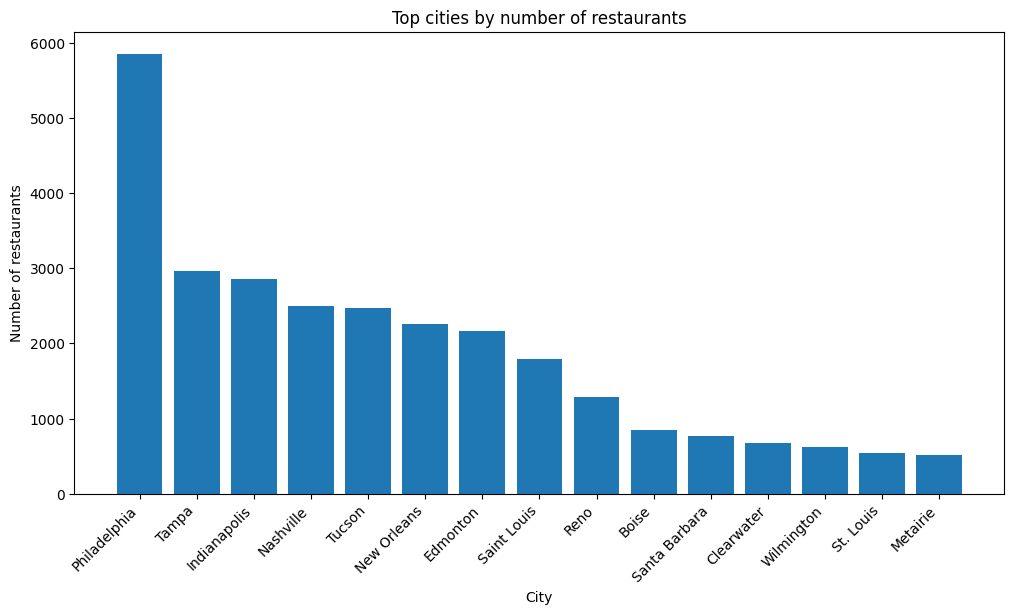

In [17]:
top_cities = city_stats.head(15)

plt.figure(figsize=(12, 6))
plt.bar(top_cities["city"], top_cities["n_restaurants"])
plt.xticks(rotation=45, ha="right")
plt.title("Top cities by number of restaurants")
plt.xlabel("City")
plt.ylabel("Number of restaurants")
plt.show()

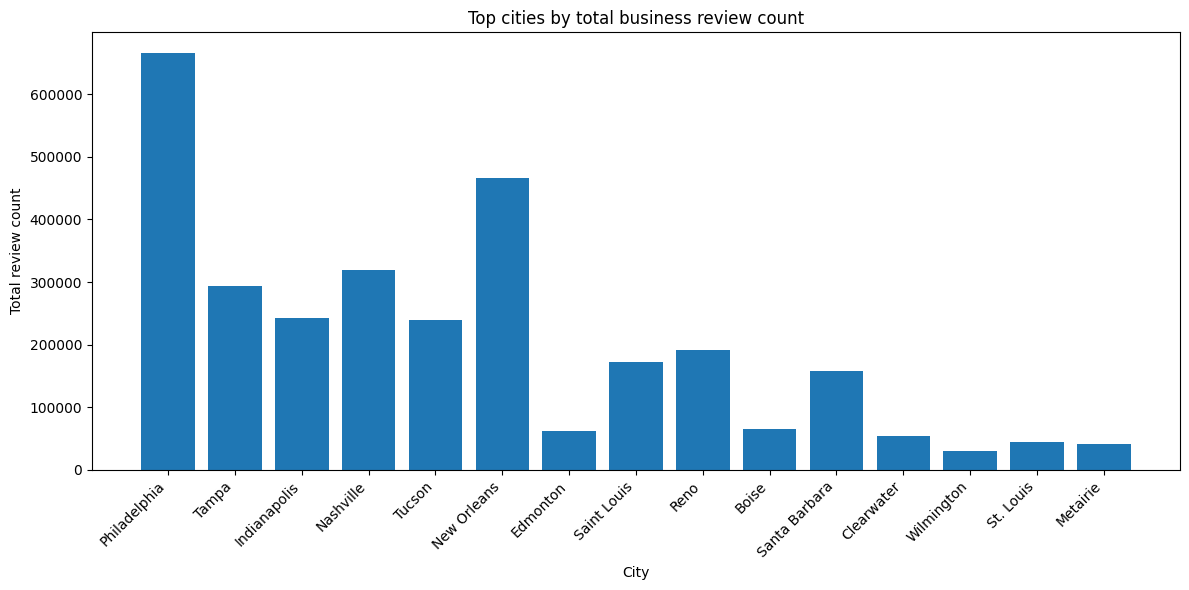

In [18]:
top_cities = city_stats.head(15)

plt.figure(figsize=(12, 6))
plt.bar(top_cities["city"], top_cities["total_business_review_count"])
plt.xticks(rotation=45, ha="right")
plt.title("Top cities by total business review count")
plt.xlabel("City")
plt.ylabel("Total review count")
plt.tight_layout()
plt.show()

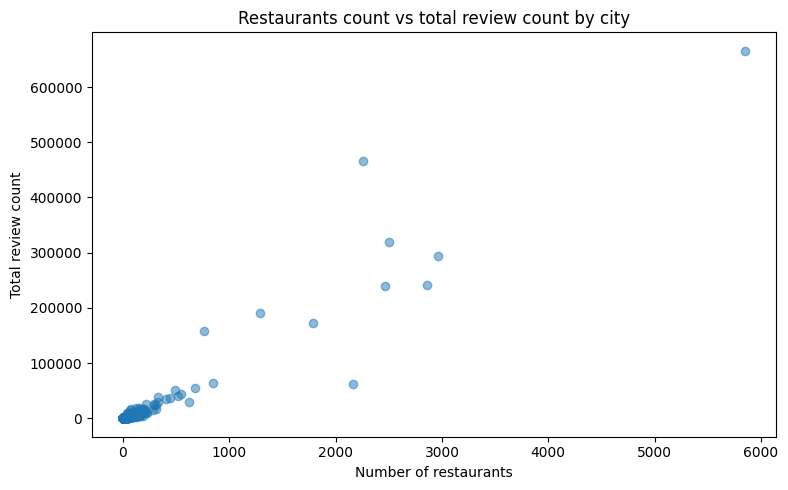

In [19]:
plt.figure(figsize=(8, 5))
plt.scatter(city_stats["n_restaurants"], city_stats["total_business_review_count"], alpha=0.5)
plt.title("Restaurants count vs total review count by city")
plt.xlabel("Number of restaurants")
plt.ylabel("Total review count")
plt.tight_layout()
plt.show()

Москва отсутствует в Yelp Open Dataset поэтому мы выбираем наиболее похожий по рынку ресторанов среди доступных городов. Город выбирается по колву ресторанов, числу отзывов, наличию истории до и после cutoff_date, разнообразию категорий и пригодности для ML-постановки

самый такой подходящий город это Филадельфия

Далее визуализируем объем отзывов по городам чтобы проверить что в выбранном городе достаточно высокая активность пользователей для генерации признаков

In [20]:
df_city = rest[rest["city"] == "Philadelphia"].copy()

df_city.shape

(5852, 14)

In [21]:
df_city[["name", "stars", "review_count", "is_open", "categories"]].head()

,name,stars,review_count,is_open,categories
3,St Honore Pastries,4.0,80,1,"Restaurants, Food, Bubble Tea, Coffee & Tea, B..."
15,Tuna Bar,4.0,245,1,"Sushi Bars, Restaurants, Japanese"
19,BAP,4.5,205,1,"Korean, Restaurants"
28,Bar One,4.0,65,0,"Cocktail Bars, Bars, Italian, Nightlife, Resta..."
31,DeSandro on Main,3.0,41,0,"Pizza, Restaurants, Salad, Soup"


#### Пишем мини функцию для очистки признаков

In [22]:
def get_attr(attrs, key):
    if isinstance(attrs, dict):
        return attrs.get(key)
    return np.nan


def clean_bool(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().lower()
    if x == "true":
        return 1
    if x == "false":
        return 0
    return np.nan


def clean_price(x):
    try:
        return int(x)
    except:
        return np.nan

из джсонов распарсим все характеристики ресторанов

In [23]:
attrs = ["RestaurantsPriceRange2","RestaurantsTakeOut","RestaurantsDelivery","RestaurantsReservations","OutdoorSeating","BusinessAcceptsCreditCards","BikeParking","GoodForKids","HasTV"]

for col in attrs: df_city[col] = df_city["attributes"].apply(lambda x: get_attr(x, col))

df_city["price"] = df_city["RestaurantsPriceRange2"].apply(clean_price)

bool_cols = attrs[1:]

for col in bool_cols: df_city[col] = df_city[col].apply(clean_bool)

#### Проверяем пропуски и сразу смотрим на среднее чтобы узнать долю пропусков

In [24]:
missing = df_city[["price"] + bool_cols].isna().mean()
missing

price                         0.156015
RestaurantsTakeOut            0.087833
RestaurantsDelivery           0.131750
RestaurantsReservations       0.184552
OutdoorSeating                0.196172
BusinessAcceptsCreditCards    0.095694
BikeParking                   0.350991
GoodForKids                   0.228811
HasTV                         0.221121
dtype: float64

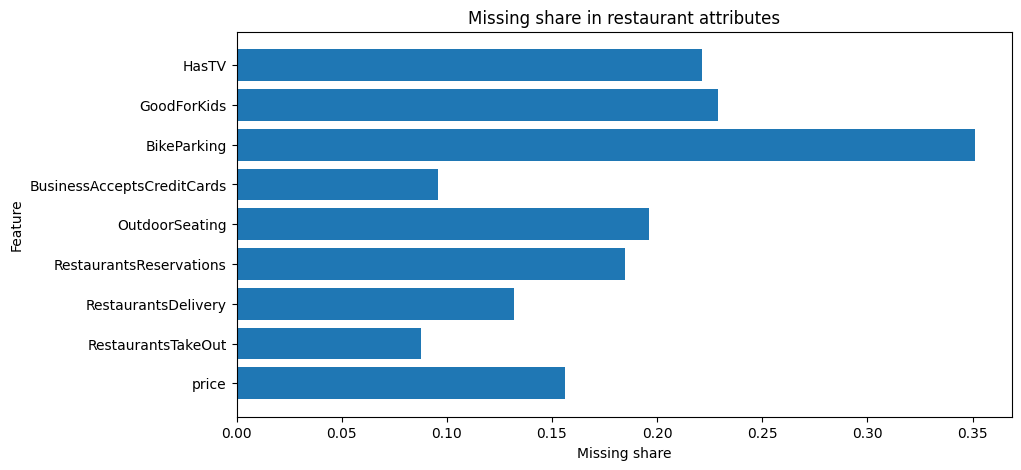

In [25]:
plt.figure(figsize=(10, 5))
plt.barh(missing.index, missing.values)
plt.title("Missing share in restaurant attributes")
plt.xlabel("Missing share")
plt.ylabel("Feature") 
plt.show()

#### Обработка пропусков

Если пропусков немного, заполняем самым частым значением или медианой.

Если пропусков больше, создаем отдельный индикатор пропуска. Это лучше, чем просто заменять все средним, потому что отсутствие информации в карточке ресторана само может быть полезным сигналом.

In [26]:
df_city["price_missing"] = df_city["price"].isna().astype(int)
df_city["price"] = df_city["price"].fillna(df_city["price"].median())

for col in bool_cols:
    df_city[col + "_missing"] = df_city[col].isna().astype(int)
    df_city[col] = df_city[col].fillna(-1)

In [27]:
df_city[["price"] + bool_cols].isna().sum()

price                         0
RestaurantsTakeOut            0
RestaurantsDelivery           0
RestaurantsReservations       0
OutdoorSeating                0
BusinessAcceptsCreditCards    0
BikeParking                   0
GoodForKids                   0
HasTV                         0
dtype: int64

Пропуски почистили - ура

#### Проверяем сбалансированность классов / оценок в городе

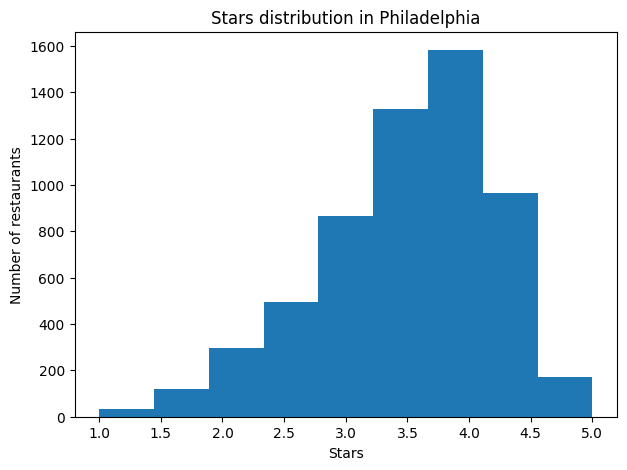

In [28]:
plt.figure(figsize=(7, 5))
plt.hist(df_city["stars"], bins=9)
plt.title("Stars distribution in Philadelphia")
plt.xlabel("Stars")
plt.ylabel("Number of restaurants") 
plt.show()

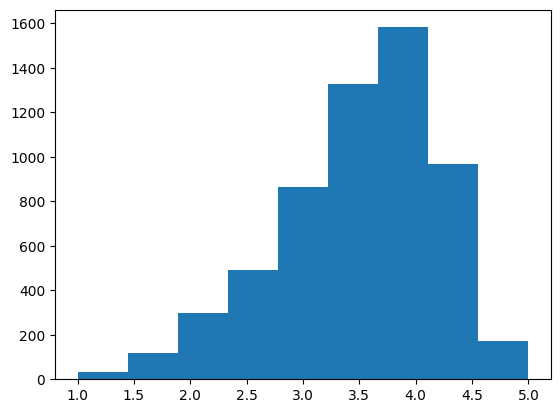

In [29]:
plt.hist(df_city["stars"], bins=9)
plt.show()

In [30]:
df_city["price"].value_counts(dropna=False) / 5852	

price
2.0    0.580656
1.0    0.369959
3.0    0.042891
4.0    0.006494
Name: count, dtype: float64

#### Сравниваем с мск
Информация взята с сайтов: 

https://www.restoclub.ru/msk/search/restorany-g-moskovskogo-srednej-cenovoj-kategorii
https://moscowrestaurant.ru/news/kolichestvo-restoranov-v-cao-moskvy-vyroslo
https://moscowrestaurant.ru/articles/samye-dorogie-restorany-moskvy
https://www.vedomosti.ru/kp/time/article/2026/06/09/1204723-proverennie-vremenem-i-tihie-kakie-restorani-vibirayut-rukovoditeli


Распределение заведений по уровню цен и среднему чеку:
Бюджетный сегмент (до 1 500 ₽): Около 40% всех точек. Это фуд-корты, фастфуд, стритфуд, демократичные кофейни и столовые

Средний чек (1 500 — 3 000 ₽): Около 45%-50% рынка. Сюда входят городские кафе, демократичные бары, пабы, сетевые рестораны и модные бистро

Премиум и Высокая кухня (свыше 3 000 ₽): Около 10% заведений. В эту категорию входят авторские рестораны, заведения высокой гастрономии, рыбные рестораны и премиальные стейк-хаусы (например, White Rabbit, Турандот или Сахалин)

соотношение в мск в целом совпадает по категории дешевых и средних по ценам, но элитных ресторанов в мск сильно больше, однако это не критично тк их масса не столь велика по отношению к остальным заведениям

#### для задач прогнозирования выживаемости бизнеса смотрим на is_open

In [31]:
df_city["is_open"].value_counts(normalize=True)

is_open
1    0.602358
0    0.397642
Name: proportion, dtype: float64

Судя по данным из интернета в Москве соотношение открывающихся и закрывающихся заведений колеблется на уровне примерно 1,5 к 1

Точно так же как и в Филадельфии : 0.6/0.4 = 1.5

Инфа:

https://nsn.fm/society/osnovatel-myasoryba-obyasnil-pochemu-segodnya-nevygodno-otkryvat-restorany

https://secrets.tbank.ru/novosti/v-moskve-zakryvautsya-restorany/

## рейтинг, отзывы и их корреляция

#### Смотрим на взаимосвязь рейтинга и активности клиентов

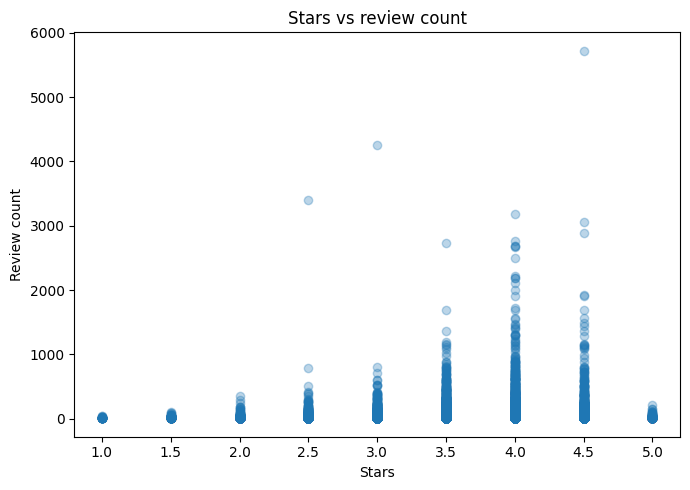

In [32]:
plt.figure(figsize=(7, 5))
plt.scatter(df_city["stars"], df_city["review_count"], alpha=0.3)
plt.title("Stars vs review count")
plt.xlabel("Stars")
plt.ylabel("Review count")
plt.tight_layout()
plt.show()

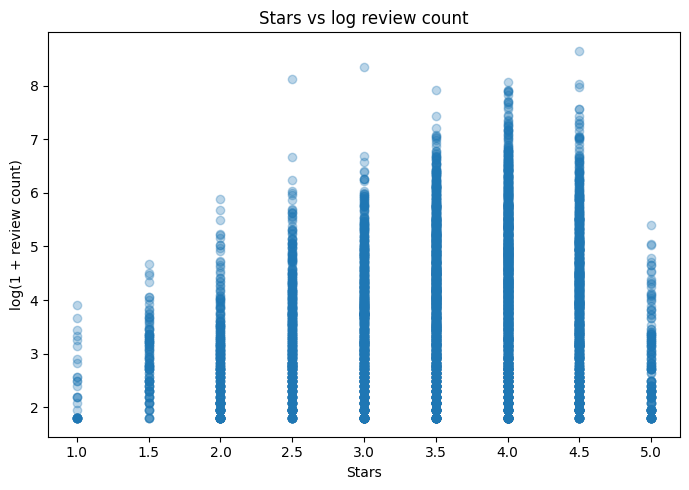

In [33]:
plt.figure(figsize=(7, 5))
plt.scatter(df_city["stars"], np.log1p(df_city["review_count"]), alpha=0.3)
plt.title("Stars vs log review count")
plt.xlabel("Stars")
plt.ylabel("log(1 + review count)")
plt.tight_layout()
plt.show()

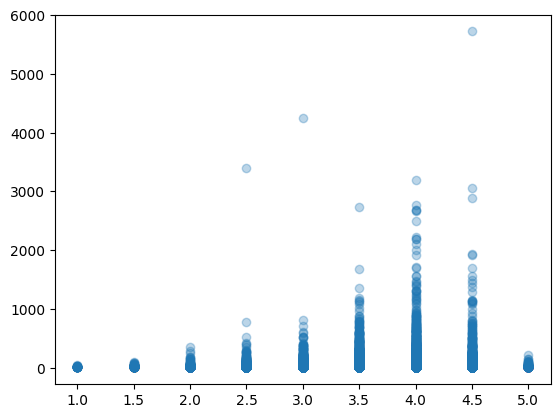

In [34]:
plt.scatter(df_city["stars"], df_city["review_count"], alpha=0.3)
plt.show()

В целом можем заметить что более расфоршенные места имеют среднюю оценку выше. оно и логично: хорошее место -> больше клиентов -> больше отзывов

#### И на корреляцию базовых очищеных признаков

In [35]:
corr_cols = ["stars", "review_count", "price"] + bool_cols

corr = df_city[corr_cols].corr()

corr

,stars,review_count,price,RestaurantsTakeOut,RestaurantsDelivery,RestaurantsReservations,OutdoorSeating,BusinessAcceptsCreditCards,BikeParking,GoodForKids,HasTV
stars,1.000000,0.145780,0.125271,-0.011299,-0.056432,0.037212,0.085031,-0.064237,0.143496,-0.085386,-0.016355
review_count,0.145780,1.000000,0.198606,0.063262,0.099753,0.214779,0.210041,0.114757,0.288747,0.121630,0.130612
price,0.125271,0.198606,1.000000,-0.172873,-0.110155,0.242353,0.068491,-0.026376,-0.072425,-0.269203,-0.066456
RestaurantsTakeOut,-0.011299,0.063262,-0.172873,1.000000,0.493503,0.231915,0.246676,0.362872,0.254328,0.354662,0.250825
RestaurantsDelivery,-0.056432,0.099753,-0.110155,0.493503,1.000000,0.140748,0.105137,0.222355,0.203877,0.213910,0.202001
RestaurantsReservations,0.037212,0.214779,0.242353,0.231915,0.140748,1.000000,0.392418,0.417453,0.237647,0.372943,0.362953
OutdoorSeating,0.085031,0.210041,0.068491,0.246676,0.105137,0.392418,1.000000,0.367139,0.318752,0.251586,0.327994
BusinessAcceptsCreditCards,-0.064237,0.114757,-0.026376,0.362872,0.222355,0.417453,0.367139,1.000000,0.347438,0.384234,0.315483
BikeParking,0.143496,0.288747,-0.072425,0.254328,0.203877,0.237647,0.318752,0.347438,1.000000,0.279568,0.369859
GoodForKids,-0.085386,0.121630,-0.269203,0.354662,0.213910,0.372943,0.251586,0.384234,0.279568,1.000000,0.367855


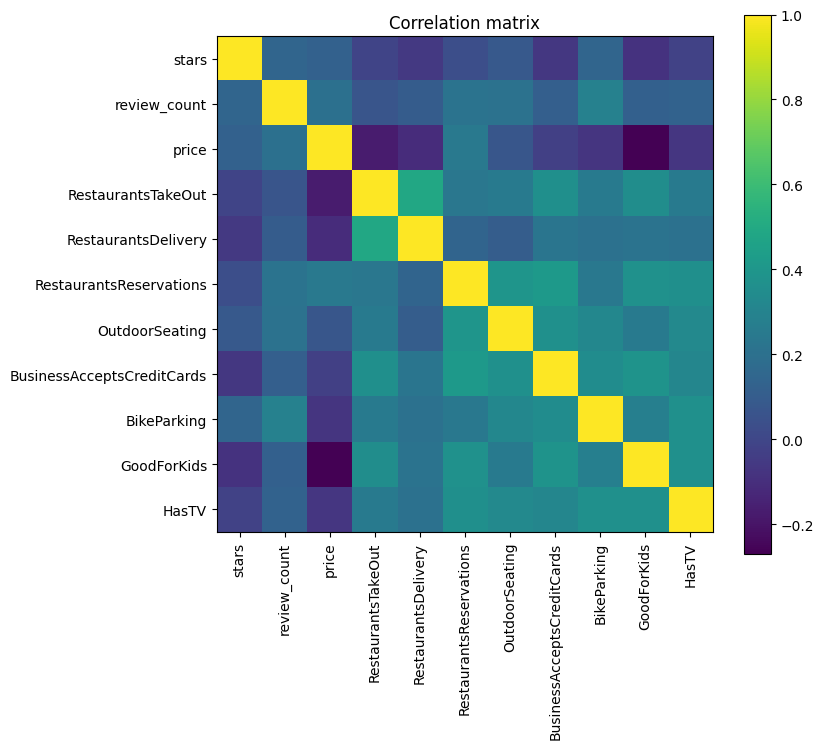

In [36]:
plt.figure(figsize=(8, 7))
plt.imshow(corr)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.title("Correlation matrix") 
plt.show()

Самый высокий коэффициент едва доходит до 0.39 это хорошо тк признаки не дублируют друг друга, каждый несет уникальную информацию

можно сделать вывод о **рейтинге заведения** (что влиеяет на него а что нет):

Связь с отзывами (0.14), есть слабая положительная корреляция между **количеством отзывов и оценкой**. Популярные места чуть чаще имеют высокий балл

Связь с ценой (0.12). **более дорогие рестораны имеют оценку чуть выше**

Прием карт (-0.13) и это интересный минус. **Места, которые не принимают карты** (или где этот флаг равен 0), внезапно **имеют чуть более высокий рейтинг**. наверное это потому, что это локальные точки для своих


Далее смотрим на **маркеры топовых мест** через review_count и оно сильнее всего коррелирует с:

BikeParking = 0.28 - доступность и трафик

RestaurantsReservations = 0.21 = OutdoorSeating - если есть веранда и бронь, заведение крупное и генерирует много фидбека

Ну и просто структурные взаимосвязи это:

**Бронь и веранда = 0.39** от есть если в ресторане можно забронировать столик, там с высокой вероятностью будет и летняя веранда. Это самый высокий коэффициент в таблице.

Семейные заведения с ТВ (0.36 - 0.37): **наличие телевизора (HasTV), парковки для велосипедов (BikeParking) и бронирования** сильно связаны с признаком **GoodForKids**. Это явный паттерн семейных или спортивных ресторанов

**Доставка и навынос (0.29)** рестики с доставкой ожидаемо коррелируют с работой навынос. При этом доставка заметно коррелирует с тем, открыто ли заведение сейчас (is_open = 0.24) т е выживают те, кто вовремя адаптировался под доставку

**а не связанно вообще is_open и stars** тк он практически никак не зависит от его рейтинга. То есть рестораны закрываются в Филадельфии не потому, что там невкусно (низкий рейтинг), а по другим, скорее всего, экономическим причинам

#### Закадируем для дальнейшей нашей работы категории рестиков и кол-ва открытых дней в векторном виде

In [37]:
cats = ["Fast Food", "Pizza", "Coffee", "Bars", "Breakfast", "Sandwiches"]

for c in cats:
    col_name = f"c_{c.lower().replace(' ', '_')}"
    df_city[col_name] = df_city['categories'].str.contains(c, case=False, na=False).astype(int)

df_city["open_days"] = df_city["hours"].apply(lambda x: len(x) if isinstance(x, dict) else 0)

#### Фильтруем и загружаем отзывы чанками

Ограничиваем id ресторанов сразу на этапе итерации, чтобы экономить память

In [38]:
r_ids = set(df_city["business_id"])
chunks = []

for ch in pd.read_json(review_json, lines=True, chunksize=100000):
    ch = ch[ch["business_id"].isin(r_ids)].copy()
    if not ch.empty:
        ch["date"] = pd.to_datetime(ch["date"])
        chunks.append(ch)

rev = pd.concat(chunks, ignore_index=True)
rev.shape

(687289, 9)

In [39]:
rev.head()

,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03
1,JrIxlS1TzJ-iCu79ul40cQ,eUta8W_HdHMXPzLBBZhL1A,04UD14gamNjLY0IDYVhHJg,1,1,2,1,I am a long term frequent customer of this est...,2015-09-23 23:10:31
2,8JFGBuHMoiNDyfcxuWNtrA,smOvOajNG0lS4Pq7d8g4JQ,RZtGWDLCAtuipwaZ-UfjmQ,4,0,0,0,Good food--loved the gnocchi with marinara\nth...,2009-10-14 19:57:14
3,oyaMhzBSwfGgemSGuZCdwQ,Dd1jQj7S-BFGqRbApFzCFw,YtSqYv1Q_pOltsVPSx54SA,5,0,0,0,Tremendous service (Big shout out to Douglas) ...,2013-06-24 11:21:25
4,Xs8Z8lmKkosqW5mw_sVAoA,IQsF3Rc6IgCzjVV9DE8KXg,eFvzHawVJofxSnD7TgbZtg,5,0,0,0,My absolute favorite cafe in the city. Their b...,2014-11-12 15:30:27


In [40]:
rev["stars"].value_counts().sort_index()

stars
1     66624
2     57480
3     91702
4    194366
5    277117
Name: count, dtype: int64

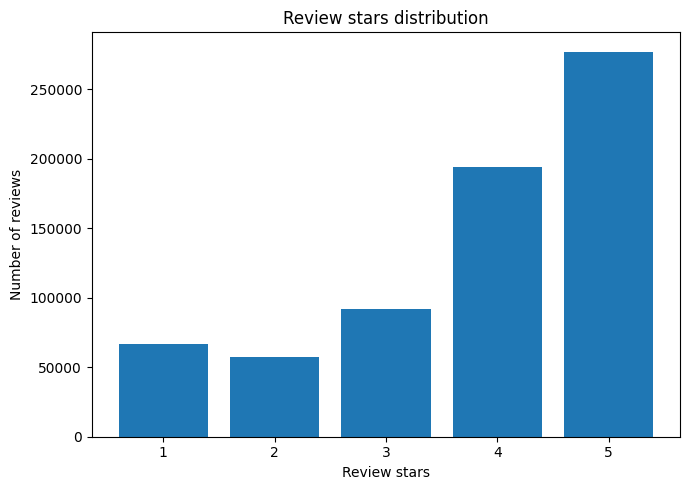

In [41]:
review_stars = rev["stars"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(review_stars.index.astype(str), review_stars.values)
plt.title("Review stars distribution")
plt.xlabel("Review stars")
plt.ylabel("Number of reviews")
plt.tight_layout()
plt.show()

In [42]:
rev["year"] = rev["date"].dt.year

reviews_by_year = (
    rev
    .groupby("year")
    .agg(
        n_reviews=("review_id", "count"),
        avg_stars=("stars", "mean")
    )
    .reset_index()
)

reviews_by_year.head()

,year,n_reviews,avg_stars
0,2005,101,3.960396
1,2006,773,3.978008
2,2007,4115,3.760875
3,2008,10912,3.685850
4,2009,18844,3.674804


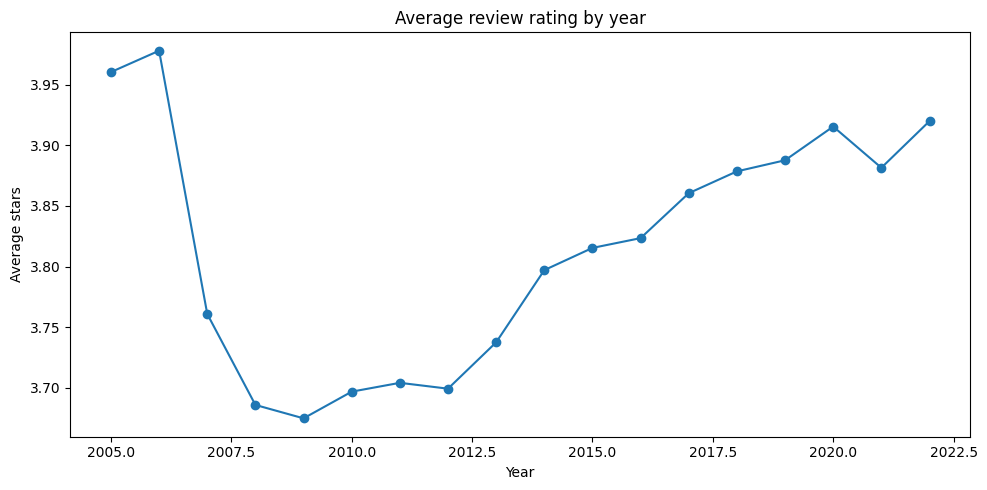

In [43]:
plt.figure(figsize=(10, 5))
plt.plot(reviews_by_year["year"], reviews_by_year["avg_stars"], marker="o")
plt.title("Average review rating by year")
plt.xlabel("Year")
plt.ylabel("Average stars")
plt.tight_layout()
plt.show()

#### Разделеляем отзывы по временной метке
Для того чтобы разделить train и test выборку

In [44]:
past = rev[rev["date"] < pd.Timestamp("2019-01-01")].copy()
future = rev[rev["date"] >= pd.Timestamp("2019-01-01")].copy()

#### Делаем базовые фичей из прошлых отзывов

In [45]:
f_past = past.groupby("business_id").agg(p_rev_cnt=("review_id", "count"), p_avg_rate=("stars", "mean"),p_std_rate=("stars", "std"),p_use_mean=("useful", "mean"), p_fun_mean=("funny", "mean"), p_cool_mean=("cool", "mean"), last_date=("date", "max")).reset_index()

f_past["p_std_rate"] = f_past["p_std_rate"].fillna(0)
f_past["days_since_last"] = (pd.Timestamp("2019-01-01") - f_past["last_date"]).dt.days
f_past = f_past.drop(columns=["last_date"])

В кратце о каждой из них:

**p_rev_cnt** - общее количество отзывов, которое ресторан успел накопить до отчетной даты

**p_avg_rate** - ср оценка ресторана, сформированная на основе прошлых отзывов

**p_std_rate** - ср кв отклонение оценок (разброс)

**p_use_mean**, **p_fun_mean**, **p_cool_mean** - ср кол-во лайков от других пользователей, которые получили отзывы на этот ресторан по категориям полезно, смешно и круто

**days_since_last** - кол-во дней, прошедших с момента самого последнего отзыва до отчетной даты таким образом измеряем активность и актуальность места

#### Проводим мини анализ тональности
Мы будем расскладывать прошлый опыт клиентов на два радикальных полюса: чистый негатив и чистый позитив, а затем смотрим на их долю в общей массе отзывов каждого ресторана.
Оценку 3 намеренно игнорируем, чтобы очистить сигнал от шума и выделить только крайние оценки

In [46]:
past_sent = (past.assign(neg=lambda x: (x["stars"] <= 2).astype(int), pos=lambda x: (x["stars"] >= 4).astype(int),)
    .groupby("business_id")
    .agg(p_neg_share=("neg", "mean"), p_pos_share=("pos", "mean"))
    .reset_index())

f_past = f_past.merge(past_sent, on="business_id", how="left")

Как итог получаем:

**p_neg_share** (доля негатива - число от 0 до 1). Если оно равно, например, 0.35, это значит, что 35% всех прошлых клиентов ушли из ресторана в ярости или глубоком разочаровании

**p_pos_share** (доля позитива) - аналогично противоположно p_neg_share.

#### Создаем таргет - то на чем наша нейросеть будет учиться предсказывать
Суть таргета такова, что мы берем будущие отзывы и агрегируем их по каждому ресторану: то сколько рестик получил отзыов в будущем (f_cnt) и какой у него ср рейтинг в будущем (f_rate)
а затем считаем критерий успешности который принимает знач 0 или 1

1 - успех, рест в будущем держит высокую планку качества и при этом генерирует стабильный поток клиентов


0 - неуспех когда рест не выполнил хотя бы одно из условий

In [47]:
f_tgt = future.groupby("business_id").agg(f_cnt=("review_id", "count"), f_rate=("stars", "mean")).reset_index()

f_tgt["target"] = ((f_tgt["f_rate"] >= 4.0) & (f_tgt["f_cnt"] >= 5)).astype(int)

In [48]:
df_target = df_city[["business_id"]].merge(f_tgt, on="business_id", how="left")

df_target["f_cnt"] = df_target["f_cnt"].fillna(0)
df_target["f_rate"] = df_target["f_rate"].fillna(0)

df_target["target"] = ((df_target["f_rate"] >= 4.0) & (df_target["f_cnt"] >= 5)).astype(int)

df_target.head()

,business_id,f_cnt,f_rate,target
0,MTSW4McQd7CbVtyjqoe9mw,20.0,4.550000,1
1,MUTTqe8uqyMdBl186RmNeA,116.0,4.163793,1
2,ROeacJQwBeh05Rqg7F6TCg,37.0,4.243243,1
3,QdN72BWoyFypdGJhhI5r7g,16.0,3.937500,0
4,Mjboz24M9NlBeiOJKLEd_Q,0.0,0.000000,0


In [49]:
target_share = df_target["target"].value_counts(normalize=True).sort_index()

target_share

target
0    0.758886
1    0.241114
Name: proportion, dtype: float64

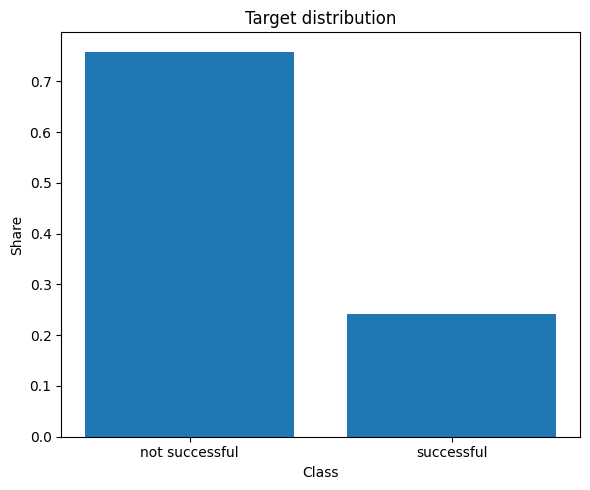

In [50]:
plt.figure(figsize=(6, 5))
plt.bar(["not successful", "successful"], target_share.values)
plt.title("Target distribution")
plt.xlabel("Class")
plt.ylabel("Share")
plt.tight_layout()
plt.show()

#### парсим чек ины

нужно чтобы оценить соотношение посещаемость / отзывы

в будущем скормим нейронке этот параметр тк он оч сильгно может повлият на наш таргет

In [51]:
chkin = pd.read_json(checkin_json, lines=True)
chkin = chkin[chkin["business_id"].isin(r_ids)].copy()

chkin["p_chkin_cnt"] = chkin["date"].str.split(", ").apply(lambda x: sum(1 for d in x if d < str(pd.Timestamp("2019-01-01"))[:10]) if isinstance(x, list) else 0)

f_chkin = chkin[["business_id", "p_chkin_cnt"]].copy()

#### Смердживаем все в финальный датасет

In [52]:
base_cols = ["business_id", "latitude", "longitude", "price", "open_days"]

category_cols = [f"c_{c.lower().replace(' ', '_')}" for c in cats]
missing_cols = ["price_missing"] + [col + "_missing" for col in bool_cols]

b_cols = base_cols + bool_cols + missing_cols + category_cols

df_final = df_city[b_cols].merge(f_past, on="business_id", how="left")
df_final = df_final.merge(f_chkin, on="business_id", how="left")
df_final = df_final.merge(df_target[["business_id", "f_cnt", "f_rate", "target"]], on="business_id", how="left")

df_final.head()

,business_id,latitude,longitude,price,open_days,RestaurantsTakeOut,RestaurantsDelivery,RestaurantsReservations,OutdoorSeating,BusinessAcceptsCreditCards,...,p_use_mean,p_fun_mean,p_cool_mean,days_since_last,p_neg_share,p_pos_share,p_chkin_cnt,f_cnt,f_rate,target
0,MTSW4McQd7CbVtyjqoe9mw,39.955505,-75.155564,1.0,7,1.0,0.0,-1.0,0.0,0.0,...,1.746269,0.701493,1.283582,24.0,0.104478,0.761194,316.0,20.0,4.550000,1
1,MUTTqe8uqyMdBl186RmNeA,39.953949,-75.143226,2.0,6,1.0,1.0,1.0,1.0,1.0,...,1.537313,0.276119,0.798507,1.0,0.111940,0.783582,78.0,116.0,4.163793,1
2,ROeacJQwBeh05Rqg7F6TCg,39.943223,-75.162568,1.0,6,1.0,-1.0,0.0,-1.0,1.0,...,0.853801,0.269006,0.456140,12.0,0.046784,0.830409,188.0,37.0,4.243243,1
3,QdN72BWoyFypdGJhhI5r7g,39.939825,-75.157447,2.0,7,1.0,1.0,0.0,0.0,1.0,...,1.245283,0.396226,0.622642,57.0,0.226415,0.679245,57.0,16.0,3.937500,0
4,Mjboz24M9NlBeiOJKLEd_Q,40.022466,-75.218314,1.0,6,1.0,1.0,0.0,1.0,1.0,...,0.487805,0.097561,0.146341,133.0,0.487805,0.439024,9.0,0.0,0.000000,0


#### Заполняем пропуски после мерджа

Тут самый важный момент: средний рейтинг нельзя заполнять нулем, потому что шкала Yelp начинается с 1. Поэтому добавляем индикатор `no_past_reviews`, а `p_avg_rate` заполняем нейтральным значением 3.0.

In [53]:
df_final["no_past_reviews"] = df_final["p_rev_cnt"].isna().astype(int)

In [54]:
df_final["p_rev_cnt"] = df_final["p_rev_cnt"].fillna(0)
df_final["p_std_rate"] = df_final["p_std_rate"].fillna(0)

df_final["p_use_mean"] = df_final["p_use_mean"].fillna(0)
df_final["p_fun_mean"] = df_final["p_fun_mean"].fillna(0)
df_final["p_cool_mean"] = df_final["p_cool_mean"].fillna(0)

df_final["p_neg_share"] = df_final["p_neg_share"].fillna(0)
df_final["p_pos_share"] = df_final["p_pos_share"].fillna(0)

df_final["p_chkin_cnt"] = df_final["p_chkin_cnt"].fillna(0)

In [55]:
df_final["p_avg_rate"] = df_final["p_avg_rate"].fillna(3.0)

In [56]:
max_days = df_final["days_since_last"].max()

df_final["days_since_last"] = df_final["days_since_last"].fillna(max_days + 30)

In [57]:
df_final.isna().sum().sort_values(ascending=False).head(20)

business_id                           0
latitude                              0
longitude                             0
price                                 0
open_days                             0
RestaurantsTakeOut                    0
RestaurantsDelivery                   0
RestaurantsReservations               0
OutdoorSeating                        0
BusinessAcceptsCreditCards            0
BikeParking                           0
GoodForKids                           0
HasTV                                 0
price_missing                         0
RestaurantsTakeOut_missing            0
RestaurantsDelivery_missing           0
RestaurantsReservations_missing       0
OutdoorSeating_missing                0
BusinessAcceptsCreditCards_missing    0
BikeParking_missing                   0
dtype: int64

#### Смотрим есть ли перекос в сторону успешных/неуспешных мест

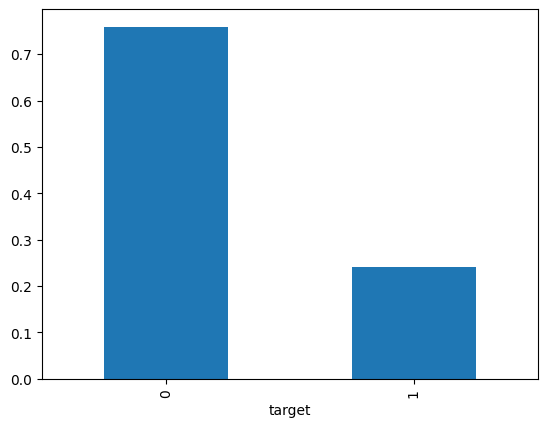

In [58]:
df_final["target"].value_counts(normalize=True).plot(kind="bar")
plt.show()

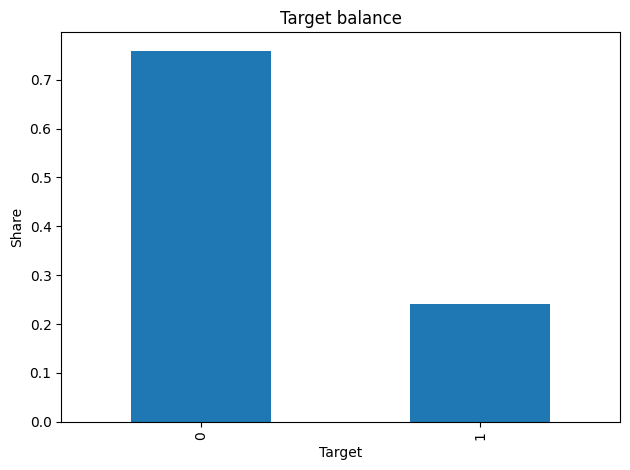

In [59]:
df_final["target"].value_counts(normalize=True).plot(kind="bar")
plt.title("Target balance")
plt.xlabel("Target")
plt.ylabel("Share")
plt.tight_layout()
plt.show()

уффф классы не сбалансированы (выживает сильнейший) (не каждому дано)

#### Анализируем плотность рестов

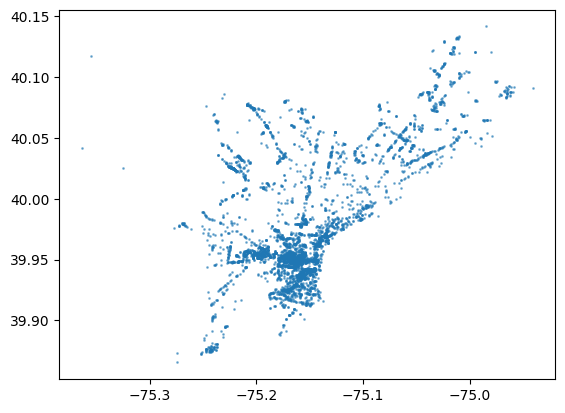

In [60]:
plt.scatter(df_final["longitude"], df_final["latitude"], alpha=0.5, s=1)
plt.show()

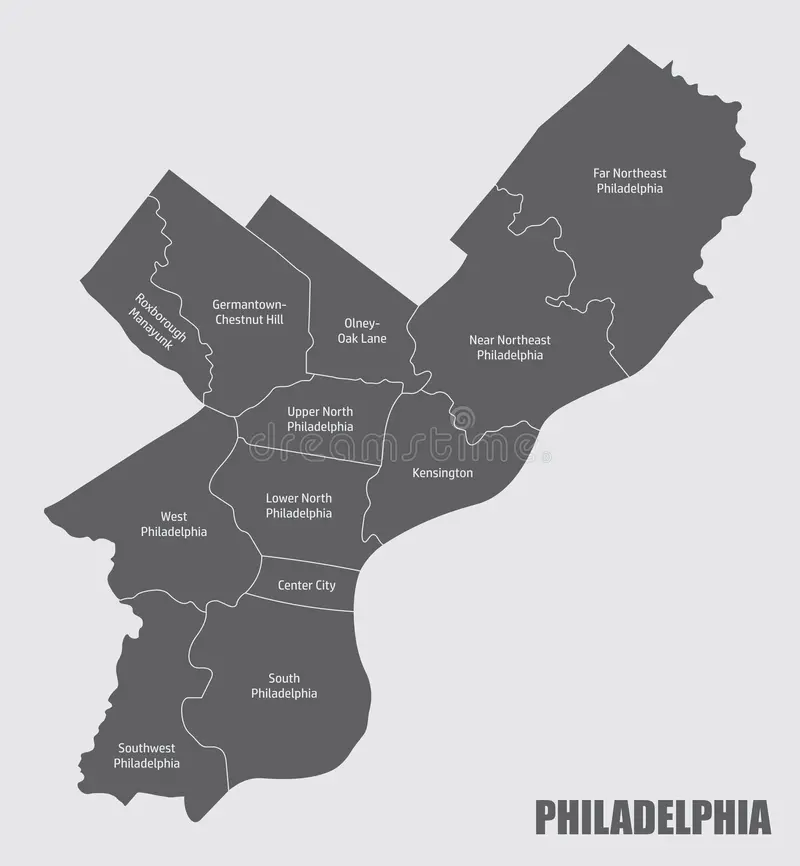
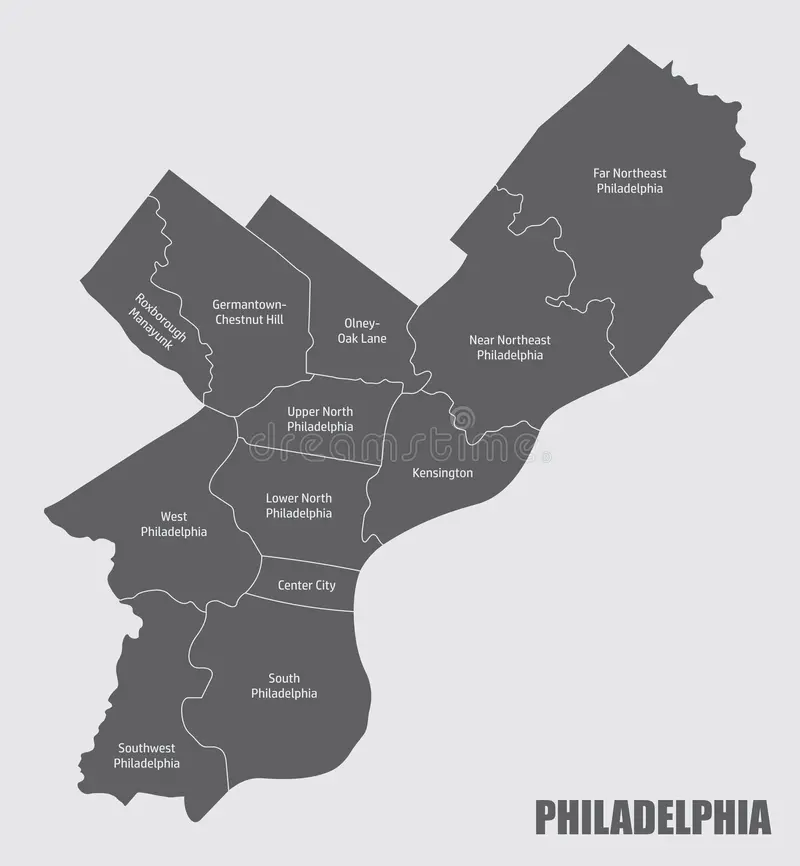

похоже чем то мск, ну на половину мск тянет

#### Разделяем очищенные данные на три независимые выборки: обучающую, валидационную и тестовую

In [61]:
future_cols = ["f_cnt", "f_rate"]

X = df_final.drop(columns=["business_id", "target"] + future_cols)
y = df_final["target"]

X.shape, y.shape

((5852, 38), (5852,))

In [62]:
future_cols = ["f_cnt", "f_rate"]

X = df_final.drop(columns=["business_id", "target"] + future_cols)
y = df_final["target"]

assert "target" not in X.columns
assert "f_cnt" not in X.columns
assert "f_rate" not in X.columns

X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=0.5, random_state=42, stratify=y_tmp)

#### Проверка, что в признаки не попали будущие агрегаты

In [63]:
bad_cols = [col for col in ["f_cnt", "f_rate", "target"] if col in X.columns]

bad_cols

[]

#### Проверяем, что среднее значение таргета везде одинаково, чтобы нейронка не ловила галлюцинации

In [64]:
pd.DataFrame({
    "train": [y_tr.mean()],
    "val": [y_val.mean()],
    "test": [y_te.mean()]
})

,train,val,test
0,0.241211,0.241458,0.240319


# ML part 1

На этом этапе мы обучаем модель, которая по признакам ресторана до cutoff_date предсказывает, будет ли ресторан успешным в будущем.

Целевая переменная target равна 1, если после cutoff_date ресторан сохраняет высокий средний рейтинг и получает достаточное количество будущих отзывов. Это приближает задачу к бизнес-сценарию Yelp: заранее определить рестораны с высоким потенциалом и рестораны, которым может понадобиться дополнительное внимание платформы.

В качестве основной модели используется MLP, то есть полносвязная нейронная сеть для табличных данных. На вход модели подаются признаки ресторана: география, ценовой сегмент, категории, атрибуты, исторические агрегаты по отзывам, доля негативных и позитивных отзывов, а также количество прошлых check-ins.

Мы сравниваем несколько архитектур MLP и несколько оптимизаторов. Основная гипотеза эксперимента: более глубокая MLP с регуляризацией может лучше улавливать нелинейные связи между признаками, а Muon может ускорить или стабилизировать обучение скрытых линейных слоёв по сравнению с AdamW.

https://ru.wikipedia.org/wiki/%D0%9C%D0%BD%D0%BE%D0%B3%D0%BE%D1%81%D0%BB%D0%BE%D0%B9%D0%BD%D1%8B%D0%B9_%D0%BF%D0%B5%D1%80%D1%86%D0%B5%D0%BF%D1%82%D1%80%D0%BE%D0%BD_%D0%A0%D1%83%D0%BC%D0%B5%D0%BB%D1%8C%D1%85%D0%B0%D1%80%D1%82%D0%B0

In [65]:
batch_size = 128
epochs = 30

In [66]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [67]:
scaler = StandardScaler()

X_tr_scaled = scaler.fit_transform(X_tr)
X_val_scaled = scaler.transform(X_val)
X_te_scaled = scaler.transform(X_te)

In [68]:
X_tr_tensor = torch.tensor(X_tr_scaled, dtype=torch.float32)
y_tr_tensor = torch.tensor(y_tr.values, dtype=torch.float32).view(-1, 1)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

X_te_tensor = torch.tensor(X_te_scaled, dtype=torch.float32)
y_te_tensor = torch.tensor(y_te.values, dtype=torch.float32).view(-1, 1)

In [69]:
train_data = TensorDataset(X_tr_tensor, y_tr_tensor)
val_data = TensorDataset(X_val_tensor, y_val_tensor)
test_data = TensorDataset(X_te_tensor, y_te_tensor)

In [70]:
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

#### Простое логирование экспериментов в MLflow

In [83]:

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("yelp_tabular_success")


artifact_dir = Path("mlflow_artifacts")
artifact_dir.mkdir(exist_ok=True)


def save_common_artifacts():
    features_path = artifact_dir / "features.json"
    scaler_path = artifact_dir / "scaler.pkl"

    with open(features_path, "w", encoding="utf-8") as f:
        json.dump(list(X.columns), f, ensure_ascii=False, indent=2)

    joblib.dump(scaler, scaler_path)
    return features_path, scaler_path


def log_common_artifacts():
    features_path, scaler_path = save_common_artifacts()
    mlflow.log_artifact(str(features_path))
    mlflow.log_artifact(str(scaler_path))


def log_torch_experiment(name, model, history, test_metrics, params):
    if not use_mlflow:
        return

    try:
        with mlflow.start_run(run_name=name):
            mlflow.log_params(params)

            for _, row in history.iterrows():
                epoch = int(row["epoch"])
                mlflow.log_metric("train_loss", float(row["train_loss"]), step=epoch)
                mlflow.log_metric("train_roc_auc", float(row["train_roc_auc"]), step=epoch)
                mlflow.log_metric("val_roc_auc", float(row["val_roc_auc"]), step=epoch)
                mlflow.log_metric("val_pr_auc", float(row["val_pr_auc"]), step=epoch)
                mlflow.log_metric("val_f1", float(row["val_f1"]), step=epoch)
                mlflow.log_metric("val_recall", float(row["val_recall"]), step=epoch)

            for metric_name, metric_value in test_metrics.items():
                if metric_name == "model":
                    continue
                if metric_name in ["roc_auc", "pr_auc", "accuracy", "f1", "precision", "recall"]:
                    mlflow.log_metric("test_" + metric_name, float(metric_value))
                else:
                    mlflow.log_metric(metric_name, float(metric_value))

            log_common_artifacts()
            mlflow.pytorch.log_model(model, "model")

    except Exception as e:
        print("MLflow logging skipped:", e)


def log_sklearn_experiment(name, model, test_metrics, params):
    if not use_mlflow:
        return

    try:
        with mlflow.start_run(run_name=name):
            mlflow.log_params(params)

            for metric_name, metric_value in test_metrics.items():
                if metric_name == "model":
                    continue
                if metric_name in ["roc_auc", "pr_auc", "accuracy", "f1", "precision", "recall"]:
                    mlflow.log_metric("test_" + metric_name, float(metric_value))
                else:
                    mlflow.log_metric(metric_name, float(metric_value))

            log_common_artifacts()

            mlflow.sklearn.log_model(model, "model")

    except Exception as e:
        print("MLflow logging skipped:", e)

In [84]:
class MLP(nn.Module):
    def __init__(self, input_size, hidden_layers, dropout=0.0):
        super().__init__()
        
        layers = []
        prev_size = input_size
        
        for hidden_size in hidden_layers:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            
            prev_size = hidden_size
        
        layers.append(nn.Linear(prev_size, 1))
        
        self.model = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.model(x)

In [85]:
def predict(model, loader):
    model.eval()
    
    probs = []
    true = []
    
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            
            logits = model(x_batch)
            batch_probs = torch.sigmoid(logits).cpu().numpy()
            
            probs.extend(batch_probs.ravel())
            true.extend(y_batch.numpy().ravel())
    
    return np.array(probs), np.array(true)

In [86]:
def get_metrics(model, loader):
    probs, true = predict(model, loader)
    preds = (probs >= 0.5).astype(int)
    
    return {
        "roc_auc": roc_auc_score(true, probs),
        "pr_auc": average_precision_score(true, probs),
        "accuracy": accuracy_score(true, preds),
        "f1": f1_score(true, preds),
        "precision": precision_score(true, preds, zero_division=0),
        "recall": recall_score(true, preds, zero_division=0)
    }

In [87]:
def train_mlp(name, hidden_layers, dropout=0.0, lr=0.001, epochs=30):
    input_size = X_tr_scaled.shape[1]

    model = MLP(
        input_size=input_size,
        hidden_layers=hidden_layers,
        dropout=dropout
    ).to(device)

    pos_count = y_tr.sum()
    neg_count = len(y_tr) - pos_count
    pos_weight = torch.tensor([neg_count / pos_count], dtype=torch.float32).to(device)

    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    history = []
    best_val_auc = -1
    best_epoch = 0
    best_state = None

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0

        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            logits = model(x_batch)
            loss = loss_fn(logits, y_batch)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        train_loss = total_loss / len(train_loader)

        train_metrics = get_metrics(model, train_loader)
        val_metrics = get_metrics(model, val_loader)

        history.append({
            "model": name,
            "epoch": epoch,
            "train_loss": train_loss,
            "train_roc_auc": train_metrics["roc_auc"],
            "val_roc_auc": val_metrics["roc_auc"],
            "val_pr_auc": val_metrics["pr_auc"],
            "val_f1": val_metrics["f1"],
            "val_recall": val_metrics["recall"]
        })

        if val_metrics["roc_auc"] > best_val_auc:
            best_val_auc = val_metrics["roc_auc"]
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())

        print(
            name,
            "| epoch:", epoch,
            "| loss:", round(train_loss, 4),
            "| val_auc:", round(val_metrics["roc_auc"], 4),
            "| val_f1:", round(val_metrics["f1"], 4)
        )

    model.load_state_dict(best_state)

    test_metrics = get_metrics(model, test_loader)
    test_metrics["model"] = name
    test_metrics["val_roc_auc"] = best_val_auc
    test_metrics["best_epoch"] = best_epoch

    log_torch_experiment(
        name=name,
        model=model,
        history=pd.DataFrame(history),
        test_metrics=test_metrics,
        params={
            "model_type": "MLP",
            "hidden_layers": str(hidden_layers),
            "dropout": dropout,
            "lr": lr,
            "epochs": epochs,
            "batch_size": batch_size,
            "optimizer": "AdamW",
            "loss": "BCEWithLogitsLoss_pos_weight",
            "cutoff_date": "2019-01-01"
        }
    )

    return model, pd.DataFrame(history), test_metrics

In [88]:
from sklearn.linear_model import LogisticRegression

In [89]:
logreg = LogisticRegression(max_iter=1000, class_weight="balanced")

logreg.fit(X_tr_scaled, y_tr)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [90]:
logreg_val_probs = logreg.predict_proba(X_val_scaled)[:, 1]
logreg_probs = logreg.predict_proba(X_te_scaled)[:, 1]
logreg_preds = (logreg_probs >= 0.5).astype(int)

logreg_result = {
    "model": "logistic_regression",
    "val_roc_auc": roc_auc_score(y_val, logreg_val_probs),
    "best_epoch": np.nan,
    "roc_auc": roc_auc_score(y_te, logreg_probs),
    "pr_auc": average_precision_score(y_te, logreg_probs),
    "accuracy": accuracy_score(y_te, logreg_preds),
    "f1": f1_score(y_te, logreg_preds),
    "precision": precision_score(y_te, logreg_preds, zero_division=0),
    "recall": recall_score(y_te, logreg_preds, zero_division=0)
}

log_sklearn_experiment(
    name="logistic_regression",
    model=logreg,
    test_metrics=logreg_result,
    params={
        "model_type": "LogisticRegression",
        "max_iter": 1000,
        "class_weight": "balanced",
        "cutoff_date": "2019-01-01"
    }
)

logreg_result

2026/06/12 16:53:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


MLflow logging skipped: (raised as a result of Query-invoked autoflush; consider using a session.no_autoflush block if this flush is occurring prematurely)
(sqlite3.IntegrityError) UNIQUE constraint failed: metrics.key, metrics.timestamp, metrics.step, metrics.run_uuid, metrics.value, metrics.is_nan
[SQL: INSERT INTO metrics ("key", value, timestamp, step, is_nan, run_uuid) VALUES (?, ?, ?, ?, ?, ?)]
[parameters: ('best_epoch', 0.0, 1781283230672, 0, 1, '2347135b6bd942668ada0f907092f9d5')]
(Background on this error at: https://sqlalche.me/e/20/gkpj)


{'model': 'logistic_regression',
 'val_roc_auc': np.float64(0.8838673579239616),
 'best_epoch': nan,
 'roc_auc': np.float64(0.9113097479696171),
 'pr_auc': np.float64(0.7607330039839285),
 'accuracy': 0.8097949886104784,
 'f1': 0.6969147005444646,
 'precision': 0.5647058823529412,
 'recall': 0.909952606635071}

несколько MLP

In [91]:
results = [logreg_result]
histories = {}
models = {}

In [92]:
model_1, hist_1, res_1 = train_mlp(
    name="mlp_small",
    hidden_layers=[64, 32],
    dropout=0.0,
    lr=0.001,
    epochs=30
)

models["mlp_small"] = model_1
histories["mlp_small"] = hist_1
results.append(res_1)

mlp_small | epoch: 1 | loss: 1.0061 | val_auc: 0.8216 | val_f1: 0.556
mlp_small | epoch: 2 | loss: 0.8203 | val_auc: 0.854 | val_f1: 0.6144
mlp_small | epoch: 3 | loss: 0.6911 | val_auc: 0.8666 | val_f1: 0.6256
mlp_small | epoch: 4 | loss: 0.655 | val_auc: 0.872 | val_f1: 0.6187
mlp_small | epoch: 5 | loss: 0.6367 | val_auc: 0.8715 | val_f1: 0.644
mlp_small | epoch: 6 | loss: 0.6199 | val_auc: 0.877 | val_f1: 0.6406
mlp_small | epoch: 7 | loss: 0.6061 | val_auc: 0.8785 | val_f1: 0.6465
mlp_small | epoch: 8 | loss: 0.5944 | val_auc: 0.8785 | val_f1: 0.65
mlp_small | epoch: 9 | loss: 0.5817 | val_auc: 0.8807 | val_f1: 0.65
mlp_small | epoch: 10 | loss: 0.5702 | val_auc: 0.8803 | val_f1: 0.6642
mlp_small | epoch: 11 | loss: 0.5602 | val_auc: 0.8823 | val_f1: 0.6512
mlp_small | epoch: 12 | loss: 0.5525 | val_auc: 0.8813 | val_f1: 0.6618
mlp_small | epoch: 13 | loss: 0.542 | val_auc: 0.8817 | val_f1: 0.6605
mlp_small | epoch: 14 | loss: 0.5354 | val_auc: 0.8821 | val_f1: 0.6641
mlp_small | 

2026/06/12 16:54:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/12 16:54:04 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/12 16:54:04 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/06/12 16:54:19 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.25.0+cu128) contains a local version

In [94]:
model_2, hist_2, res_2 = train_mlp(
    name="mlp_medium",
    hidden_layers=[128, 64, 32],
    dropout=0.1,
    lr=0.001,
    epochs=30
)

models["mlp_medium"] = model_2
histories["mlp_medium"] = hist_2
results.append(res_2)

mlp_medium | epoch: 1 | loss: 0.9883 | val_auc: 0.8359 | val_f1: 0.6038
mlp_medium | epoch: 2 | loss: 0.7373 | val_auc: 0.8594 | val_f1: 0.6123
mlp_medium | epoch: 3 | loss: 0.6809 | val_auc: 0.8637 | val_f1: 0.6177
mlp_medium | epoch: 4 | loss: 0.6488 | val_auc: 0.8698 | val_f1: 0.6215
mlp_medium | epoch: 5 | loss: 0.6398 | val_auc: 0.8667 | val_f1: 0.634
mlp_medium | epoch: 6 | loss: 0.621 | val_auc: 0.8751 | val_f1: 0.6432
mlp_medium | epoch: 7 | loss: 0.5988 | val_auc: 0.8771 | val_f1: 0.6456
mlp_medium | epoch: 8 | loss: 0.5832 | val_auc: 0.8775 | val_f1: 0.6642
mlp_medium | epoch: 9 | loss: 0.5786 | val_auc: 0.8788 | val_f1: 0.6524
mlp_medium | epoch: 10 | loss: 0.5558 | val_auc: 0.8814 | val_f1: 0.6679
mlp_medium | epoch: 11 | loss: 0.5519 | val_auc: 0.8799 | val_f1: 0.6476
mlp_medium | epoch: 12 | loss: 0.5365 | val_auc: 0.8803 | val_f1: 0.6429
mlp_medium | epoch: 13 | loss: 0.5374 | val_auc: 0.8836 | val_f1: 0.6438
mlp_medium | epoch: 14 | loss: 0.5209 | val_auc: 0.8835 | val_

2026/06/12 16:54:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/12 16:54:46 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/12 16:54:46 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/06/12 16:54:58 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.25.0+cu128) contains a local version

In [95]:
model_3, hist_3, res_3 = train_mlp(
    name="mlp_big_dropout",
    hidden_layers=[256, 128, 64],
    dropout=0.3,
    lr=0.001,
    epochs=30
)

models["mlp_big_dropout"] = model_3
histories["mlp_big_dropout"] = hist_3
results.append(res_3)

mlp_big_dropout | epoch: 1 | loss: 0.915 | val_auc: 0.8498 | val_f1: 0.5965
mlp_big_dropout | epoch: 2 | loss: 0.7123 | val_auc: 0.8605 | val_f1: 0.6203
mlp_big_dropout | epoch: 3 | loss: 0.6713 | val_auc: 0.8654 | val_f1: 0.6192
mlp_big_dropout | epoch: 4 | loss: 0.6559 | val_auc: 0.87 | val_f1: 0.6445
mlp_big_dropout | epoch: 5 | loss: 0.6314 | val_auc: 0.8722 | val_f1: 0.629
mlp_big_dropout | epoch: 6 | loss: 0.62 | val_auc: 0.8779 | val_f1: 0.6388
mlp_big_dropout | epoch: 7 | loss: 0.6116 | val_auc: 0.877 | val_f1: 0.6246
mlp_big_dropout | epoch: 8 | loss: 0.5972 | val_auc: 0.8765 | val_f1: 0.6601
mlp_big_dropout | epoch: 9 | loss: 0.597 | val_auc: 0.8789 | val_f1: 0.6546
mlp_big_dropout | epoch: 10 | loss: 0.57 | val_auc: 0.8833 | val_f1: 0.6431
mlp_big_dropout | epoch: 11 | loss: 0.5693 | val_auc: 0.88 | val_f1: 0.658
mlp_big_dropout | epoch: 12 | loss: 0.5482 | val_auc: 0.8806 | val_f1: 0.6529
mlp_big_dropout | epoch: 13 | loss: 0.5599 | val_auc: 0.8843 | val_f1: 0.6593
mlp_big_

2026/06/12 16:55:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/12 16:55:05 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/12 16:55:05 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/06/12 16:55:17 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.25.0+cu128) contains a local version

In [96]:
results_df = pd.DataFrame(results)

results_df = results_df[
    ["model", "val_roc_auc", "best_epoch", "roc_auc", "pr_auc", "accuracy", "f1", "precision", "recall"]
]

results_df.sort_values("val_roc_auc", ascending=False)

,model,val_roc_auc,best_epoch,roc_auc,pr_auc,accuracy,f1,precision,recall
3,mlp_medium,0.885355,18.0,0.898243,0.746785,0.833713,0.704453,0.614841,0.824645
1,mlp_small,0.884384,15.0,0.900438,0.756385,0.809795,0.690167,0.567073,0.881517
4,mlp_big_dropout,0.884285,13.0,0.898776,0.730509,0.800683,0.681239,0.553254,0.886256
0,logistic_regression,0.883867,NaN,0.911310,0.760733,0.809795,0.696915,0.564706,0.909953
2,mlp_medium,0.882784,20.0,0.898399,0.726361,0.809795,0.691312,0.566667,0.886256


In [97]:
best_mlp_name = (
    results_df[results_df["model"] != "logistic_regression"]
    .sort_values("val_roc_auc", ascending=False)
    .iloc[0]["model"]
)

best_mlp_name

'mlp_medium'

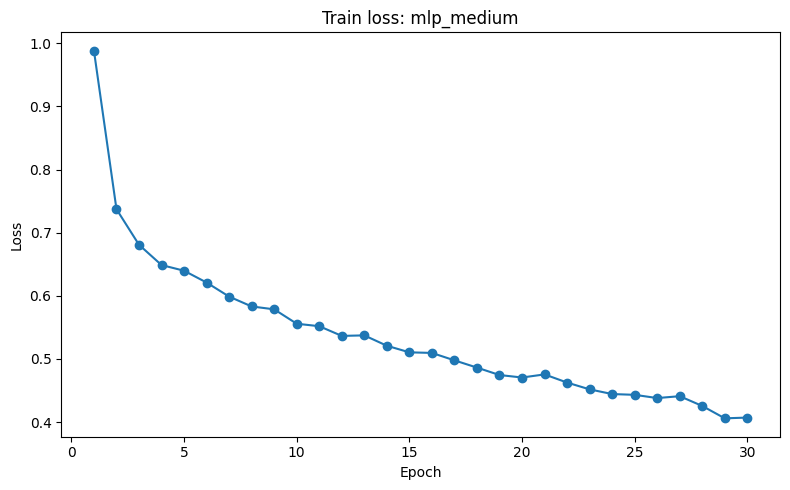

In [98]:
best_history = histories[best_mlp_name]

plt.figure(figsize=(8, 5))
plt.plot(best_history["epoch"], best_history["train_loss"], marker="o")
plt.title(f"Train loss: {best_mlp_name}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()

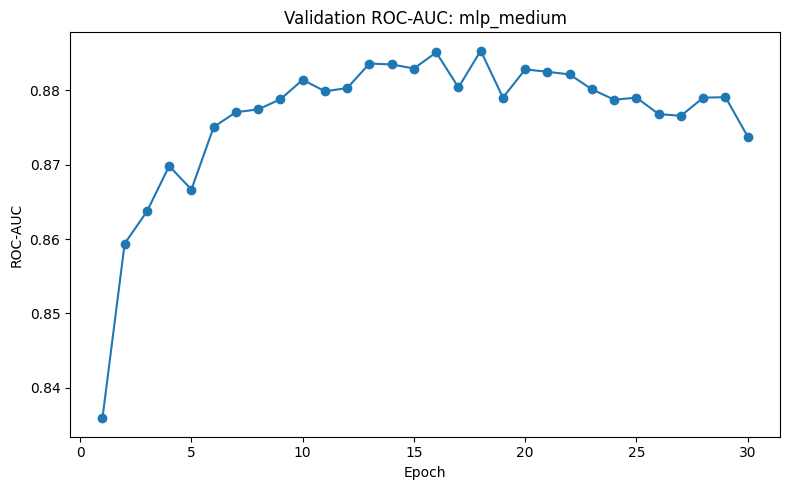

In [99]:
plt.figure(figsize=(8, 5))
plt.plot(best_history["epoch"], best_history["val_roc_auc"], marker="o")
plt.title(f"Validation ROC-AUC: {best_mlp_name}")
plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")
plt.tight_layout()
plt.show()

In [100]:
best_model = models[best_mlp_name]

test_probs, test_true = predict(best_model, test_loader)
test_preds = (test_probs >= 0.5).astype(int)

confusion_matrix(test_true, test_preds)

array([[558, 109],
       [ 37, 174]])

In [101]:
print(classification_report(test_true, test_preds))

              precision    recall  f1-score   support

         0.0       0.94      0.84      0.88       667
         1.0       0.61      0.82      0.70       211

    accuracy                           0.83       878
   macro avg       0.78      0.83      0.79       878
weighted avg       0.86      0.83      0.84       878



## MUON !

После базовых MLP-моделей с AdamW проверим Muon optimizer. Muon предназначен для матричных весов скрытых слоев нейросети. Поэтому мы применяем его только к весам hidden Linear layers, а bias и выходной слой обучаем через AdamW.

Такое сравнение честное: архитектура остается такой же, как у `mlp_big_dropout`, меняется только оптимизатор.

In [102]:
try:
    from torch.optim import Muon
    muon_available = True
except ImportError:
    Muon = None
    muon_available = False
    print("Muon optimizer is not available in this PyTorch version, so this experiment will be skipped.")

In [103]:
def split_params_for_muon(model):
    linear_layers = []

    for layer in model.model:
        if isinstance(layer, nn.Linear):
            linear_layers.append(layer)

    hidden_layers = linear_layers[:-1]
    output_layer = linear_layers[-1]

    muon_params = []
    adam_params = []

    for layer in hidden_layers:
        muon_params.append(layer.weight)

        if layer.bias is not None:
            adam_params.append(layer.bias)

    adam_params.append(output_layer.weight)

    if output_layer.bias is not None:
        adam_params.append(output_layer.bias)

    return muon_params, adam_params

In [104]:
def train_mlp_torch_muon(name, hidden_layers, dropout=0.3, adam_lr=0.001, muon_lr=0.005, epochs=30):
    input_size = X_tr_scaled.shape[1]

    model = MLP(
        input_size=input_size,
        hidden_layers=hidden_layers,
        dropout=dropout
    ).to(device)

    muon_params, adam_params = split_params_for_muon(model)

    opt_muon = Muon(muon_params, lr=muon_lr, momentum=0.95, weight_decay=0.0001)
    opt_adam = torch.optim.AdamW(adam_params, lr=adam_lr, weight_decay=0.0001)

    pos_count = y_tr.sum()
    neg_count = len(y_tr) - pos_count

    pos_weight = torch.tensor([neg_count / pos_count], dtype=torch.float32).to(device)

    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    history = []

    best_auc = -1
    best_epoch = 0
    best_state = None

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0

        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            opt_muon.zero_grad()
            opt_adam.zero_grad()

            logits = model(x_batch)
            loss = loss_fn(logits, y_batch)

            loss.backward()

            opt_muon.step()
            opt_adam.step()

            total_loss += loss.item()

        train_loss = total_loss / len(train_loader)

        train_metrics = get_metrics(model, train_loader)
        val_metrics = get_metrics(model, val_loader)

        history.append({
            "model": name,
            "epoch": epoch,
            "train_loss": train_loss,
            "train_roc_auc": train_metrics["roc_auc"],
            "val_roc_auc": val_metrics["roc_auc"],
            "val_pr_auc": val_metrics["pr_auc"],
            "val_f1": val_metrics["f1"],
            "val_recall": val_metrics["recall"]
        })

        if val_metrics["roc_auc"] > best_auc:
            best_auc = val_metrics["roc_auc"]
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())

        print(
            name,
            "| epoch:", epoch,
            "| loss:", round(train_loss, 4),
            "| val_auc:", round(val_metrics["roc_auc"], 4),
            "| val_f1:", round(val_metrics["f1"], 4)
        )

    model.load_state_dict(best_state)

    test_metrics = get_metrics(model, test_loader)
    test_metrics["model"] = name
    test_metrics["val_roc_auc"] = best_auc
    test_metrics["best_epoch"] = best_epoch

    log_torch_experiment(
        name=name,
        model=model,
        history=pd.DataFrame(history),
        test_metrics=test_metrics,
        params={
            "model_type": "MLP",
            "hidden_layers": str(hidden_layers),
            "dropout": dropout,
            "adam_lr": adam_lr,
            "muon_lr": muon_lr,
            "epochs": epochs,
            "batch_size": batch_size,
            "optimizer": "Muon_plus_AdamW",
            "loss": "BCEWithLogitsLoss_pos_weight",
            "cutoff_date": "2019-01-01"
        }
    )

    return model, pd.DataFrame(history), test_metrics

In [105]:
if muon_available:
    model_muon, hist_muon, res_muon = train_mlp_torch_muon(
        name="mlp_big_dropout_torch_muon",
        hidden_layers=[256, 128, 64],
        dropout=0.3,
        adam_lr=0.001,
        muon_lr=0.005,
        epochs=30
    )
else:
    model_muon = None
    hist_muon = pd.DataFrame()
    res_muon = None

mlp_big_dropout_torch_muon | epoch: 1 | loss: 1.0188 | val_auc: 0.8354 | val_f1: 0.5754
mlp_big_dropout_torch_muon | epoch: 2 | loss: 0.9006 | val_auc: 0.8499 | val_f1: 0.605
mlp_big_dropout_torch_muon | epoch: 3 | loss: 0.7754 | val_auc: 0.8586 | val_f1: 0.6265
mlp_big_dropout_torch_muon | epoch: 4 | loss: 0.6946 | val_auc: 0.8694 | val_f1: 0.625
mlp_big_dropout_torch_muon | epoch: 5 | loss: 0.6551 | val_auc: 0.8701 | val_f1: 0.6408
mlp_big_dropout_torch_muon | epoch: 6 | loss: 0.6346 | val_auc: 0.8761 | val_f1: 0.6535
mlp_big_dropout_torch_muon | epoch: 7 | loss: 0.6173 | val_auc: 0.878 | val_f1: 0.6594
mlp_big_dropout_torch_muon | epoch: 8 | loss: 0.6063 | val_auc: 0.8803 | val_f1: 0.6486
mlp_big_dropout_torch_muon | epoch: 9 | loss: 0.5851 | val_auc: 0.8809 | val_f1: 0.6629
mlp_big_dropout_torch_muon | epoch: 10 | loss: 0.5708 | val_auc: 0.8818 | val_f1: 0.6642
mlp_big_dropout_torch_muon | epoch: 11 | loss: 0.5452 | val_auc: 0.884 | val_f1: 0.6691
mlp_big_dropout_torch_muon | epoch

2026/06/12 16:55:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/12 16:55:39 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/12 16:55:39 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/06/12 16:55:52 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.25.0+cu128) contains a local version

In [106]:
if res_muon is not None:
    models["mlp_big_dropout_torch_muon"] = model_muon
    histories["mlp_big_dropout_torch_muon"] = hist_muon
    results.append(res_muon)

In [107]:
results_df = pd.DataFrame(results)

results_df = results_df[
    ["model", "val_roc_auc", "best_epoch", "roc_auc", "pr_auc", "accuracy", "f1", "precision", "recall"]
]

results_df.sort_values("val_roc_auc", ascending=False)

,model,val_roc_auc,best_epoch,roc_auc,pr_auc,accuracy,f1,precision,recall
5,mlp_big_dropout_torch_muon,0.886594,12.0,0.890121,0.728404,0.812073,0.690432,0.571429,0.872038
3,mlp_medium,0.885355,18.0,0.898243,0.746785,0.833713,0.704453,0.614841,0.824645
1,mlp_small,0.884384,15.0,0.900438,0.756385,0.809795,0.690167,0.567073,0.881517
4,mlp_big_dropout,0.884285,13.0,0.898776,0.730509,0.800683,0.681239,0.553254,0.886256
0,logistic_regression,0.883867,NaN,0.911310,0.760733,0.809795,0.696915,0.564706,0.909953
2,mlp_medium,0.882784,20.0,0.898399,0.726361,0.809795,0.691312,0.566667,0.886256


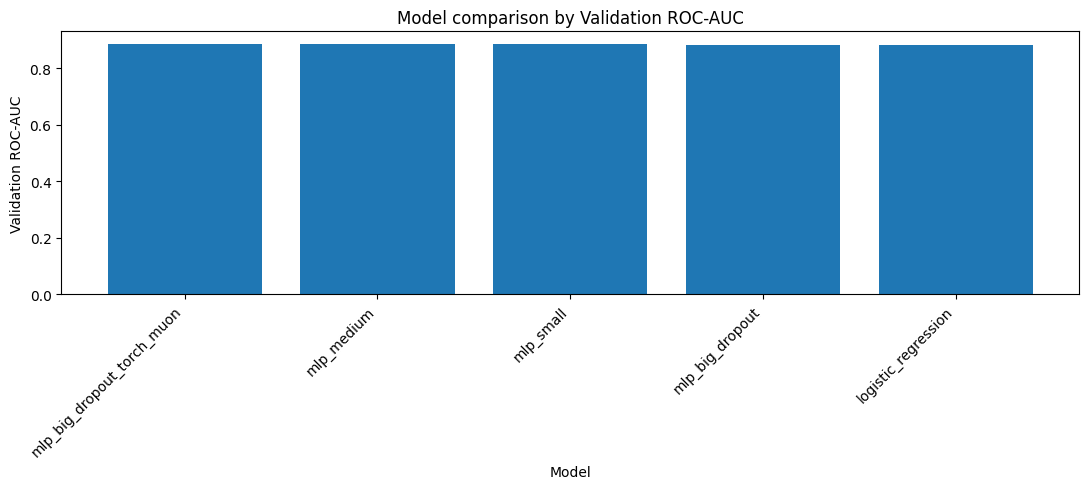

In [108]:
plot_df = results_df.sort_values("val_roc_auc", ascending=False)

plt.figure(figsize=(11, 5))
plt.bar(plot_df["model"], plot_df["val_roc_auc"])
plt.xticks(rotation=45, ha="right")
plt.title("Model comparison by Validation ROC-AUC")
plt.xlabel("Model")
plt.ylabel("Validation ROC-AUC")
plt.tight_layout()
plt.show()

## Заготовка выводов по первой части

- Лучшая модель выбирается по `val_roc_auc`, а тестовая выборка используется только для финальной проверки качества.
- После удаления будущих признаков `f_cnt` и `f_rate` качество стало честнее: модель больше не видит данные, из которых напрямую построен таргет.
- Логистическая регрессия используется как простой baseline, с которым сравниваются MLP-модели.
- Если более глубокая MLP показывает прирост относительно baseline, это можно интерпретировать как наличие нелинейных связей между признаками ресторана и будущей успешностью.
- Если прирост небольшой, значит для этой табличной задачи простые модели уже хорошо описывают основные зависимости, а усложнение архитектуры дает ограниченный эффект.
- MLflow сохраняет параметры экспериментов, метрики и артефакты модели, поэтому результаты можно воспроизвести без повторного подбора конфигурации.

In [109]:
final_results = results_df.sort_values("val_roc_auc", ascending=False)
final_results

,model,val_roc_auc,best_epoch,roc_auc,pr_auc,accuracy,f1,precision,recall
5,mlp_big_dropout_torch_muon,0.886594,12.0,0.890121,0.728404,0.812073,0.690432,0.571429,0.872038
3,mlp_medium,0.885355,18.0,0.898243,0.746785,0.833713,0.704453,0.614841,0.824645
1,mlp_small,0.884384,15.0,0.900438,0.756385,0.809795,0.690167,0.567073,0.881517
4,mlp_big_dropout,0.884285,13.0,0.898776,0.730509,0.800683,0.681239,0.553254,0.886256
0,logistic_regression,0.883867,NaN,0.911310,0.760733,0.809795,0.696915,0.564706,0.909953
2,mlp_medium,0.882784,20.0,0.898399,0.726361,0.809795,0.691312,0.566667,0.886256
